# Reproducible Code Pack — Apple Retail Portfolio Optimisation


- **Chukwuebuka Stanley Okonkwo**
- **Ludovic Vu**
- **Valentin**
- **Jean Desarnauts**

## Business Question
**How should Apple optimise its product portfolio and retail allocation strategy across international markets to maximise revenue while minimising warranty-related costs?**

## Dataset
- **Source:** [Apple Retail Sales data from kaggle](https://www.kaggle.com/datasets/amangarg08/apple-retail-sales-dataset/data)
- **Size:** 1,000,000+ rows across 5 tables
- **Tables:** category, products, sales, stores, warranty

## Analytical Methods
This notebook implements **5 complementary analytical methods**:

1. **K-Means Clustering** — Identify store-category segments with distinct revenue, quality, and operational profiles
2. **RFM Analysis** — Prioritise high-value customer segments for retention and growth strategies
3. **Conjoint Analysis** — Determine product attributes and price points that drive demand by market segment
4. **Logistic Regression** — Predict warranty claim risk and identify key drivers
5. **Sales Forecasting** — Project 6-month revenue across clusters and categories for demand planning

## How to Run This Notebook
1. **Place CSV files** (category.csv, products.csv, sales.csv, stores.csv, warranty.csv) in the same directory as this notebook
2. **Run all cells sequentially** from top to bottom (Kernel → Run All)
3. All outputs are generated in-memory; key datasets are exported as CSVs for downstream analysis
4. Execution time: ~5-10 minutes depending on hardware

---

## Section 1: Data Preparation

This section loads the five raw CSV files, standardises column names, audits data quality, parses dates, and merges into a single analysis-ready dataset.

**Pipeline:**
1. Load 5 tables from CSV
2. Standardise column names (lowercase, underscores)
3. Audit data quality (shapes, dtypes, nulls, duplicates)
4. Parse date columns
5. Sequential merge with row count validation
6. Output: `apple_merged.csv`

---

In [1]:
# ============================================================
# SECTION 1: DATA LOADING AND PREPARATION
# ============================================================
# This section loads the five raw CSV files, standardises column names,
# audits data quality, parses dates, and merges into a single analysis-ready
# dataset. The output is saved as 'apple_merged.csv'.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- 1.1 Load raw tables ---
category = pd.read_csv('category.csv')
products = pd.read_csv('products.csv')
sales = pd.read_csv('sales.csv')
stores = pd.read_csv('stores.csv')
warranty = pd.read_csv('warranty.csv')

tables = {
    'category': {'df': category, 'pk': 'category_id'},
    'products': {'df': products, 'pk': 'product_id'},
    'sales':    {'df': sales, 'pk': 'sale_id'},
    'stores':   {'df': stores, 'pk': 'store_id'},
    'warranty': {'df': warranty, 'pk': 'claim_id'},
}

# --- 1.2 Standardise column names ---
for name, info in tables.items():
    info['df'].columns = [col.lower().replace(' ', '_') for col in info['df'].columns]

# --- 1.3 Data quality audit ---
for name, info in tables.items():
    df_t = info['df']
    pk = info['pk']
    print(f"\n{'='*60}")
    print(f"  AUDIT: {name.upper()}")
    print(f"{'='*60}")
    print(f"Shape: {df_t.shape}")
    print(f"\nDtypes:\n{df_t.dtypes}\n")
    print(f"Nulls:\n{df_t.isnull().sum()}\n")
    dupes = df_t[pk].duplicated().sum()
    print(f"Duplicate {pk}: {dupes}")
    full_dupes = df_t.duplicated().sum()
    print(f"Full row duplicates: {full_dupes}")


  AUDIT: CATEGORY
Shape: (10, 2)

Dtypes:
category_id      object
category_name    object
dtype: object

Nulls:
category_id      0
category_name    0
dtype: int64

Duplicate category_id: 0
Full row duplicates: 0

  AUDIT: PRODUCTS
Shape: (89, 5)

Dtypes:
product_id      object
product_name    object
category_id     object
launch_date     object
price            int64
dtype: object

Nulls:
product_id      0
product_name    0
category_id     0
launch_date     0
price           0
dtype: int64

Duplicate product_id: 0
Full row duplicates: 0

  AUDIT: SALES
Shape: (1040200, 5)

Dtypes:
sale_id       object
sale_date     object
store_id      object
product_id    object
quantity       int64
dtype: object

Nulls:
sale_id       0
sale_date     0
store_id      0
product_id    0
quantity      0
dtype: int64

Duplicate sale_id: 0
Full row duplicates: 0

  AUDIT: STORES
Shape: (75, 4)

Dtypes:
store_id      object
store_name    object
city          object
country       object
dtype: object

Nulls:

In [2]:
# --- 1.4 Parse dates ---
sales['sale_date'] = pd.to_datetime(sales['sale_date'], dayfirst=True)
products['launch_date'] = pd.to_datetime(products['launch_date'])
warranty['claim_date'] = pd.to_datetime(warranty['claim_date'])

# --- 1.5 Sequential merge with validation ---
n_sales = len(sales)

df = pd.merge(sales, products, on='product_id', how='left')
assert len(df) == n_sales, f"Row count changed after products join: {len(df)} vs {n_sales}"
print(f"After products join: {df.shape}")

df = pd.merge(df, category, on='category_id', how='left')
assert len(df) == n_sales, f"Row count changed after category join: {len(df)} vs {n_sales}"
print(f"After category join: {df.shape}")

df = pd.merge(df, stores, on='store_id', how='left')
assert len(df) == n_sales, f"Row count changed after stores join: {len(df)} vs {n_sales}"
print(f"After stores join: {df.shape}")

df = pd.merge(df, warranty, on='sale_id', how='left')
print(f"After warranty join: {df.shape}")

print(f"\nFinal merged shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nNull counts:\n{df.isnull().sum()}")

# Save merged dataset
df.to_csv('apple_merged.csv', index=False)
print("\nSaved: apple_merged.csv")

After products join: (1040200, 9)
After category join: (1040200, 10)
After stores join: (1040200, 13)
After warranty join: (1040200, 16)

Final merged shape: (1040200, 16)
Columns: ['sale_id', 'sale_date', 'store_id', 'product_id', 'quantity', 'product_name', 'category_id', 'launch_date', 'price', 'category_name', 'store_name', 'city', 'country', 'claim_id', 'claim_date', 'repair_status']

Null counts:
sale_id                0
sale_date              0
store_id               0
product_id             0
quantity               0
product_name           0
category_id            0
launch_date            0
price                  0
category_name          0
store_name             0
city                   0
country                0
claim_id         1010200
claim_date       1010200
repair_status    1010200
dtype: int64

Saved: apple_merged.csv


## Section 2: K-Means Clustering for Segmentation

**Business Question:** What distinct behavioural segments exist across Apple's retail network, and how should resources be allocated differently?

**Method:** K-Means clustering on store-category level features capturing revenue, volume, pricing, product diversity, and warranty metrics.

**Output:**
- **Cluster 0** (High-Rejection Outliers): Small volume, high rejection rates, operational risk
- **Cluster 1** (Digital Services & Niche Hardware): Services, accessories, stable claims
- **Cluster 2** (Core Hardware Revenue Drivers): High-volume, premium products, dominant revenue

---

In [3]:
# ============================================================
# SECTION 2: K-MEANS CLUSTERING FOR SEGMENTATION
# ============================================================
# Business Question: What distinct behavioral segments exist across
# Apple's retail network, and how should resources be allocated differently?
#
# Method: K-Means clustering on store-category level features.
# Output: 3 clusters - Core Hardware Revenue Drivers, Digital Services
#         & Niche Hardware, High-Rejection Outliers.
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# --- 2.1 Load merged data ---
df = pd.read_csv('apple_merged.csv')
df['sale_date'] = pd.to_datetime(df['sale_date'])
df['claim_date'] = pd.to_datetime(df['claim_date'])
df['revenue'] = df['price'] * df['quantity']
df['claim_latency_days'] = (df['claim_date'] - df['sale_date']).dt.days
max_date = df['sale_date'].max()

# --- 2.2 Feature engineering at store x category level ---
store_cat = df.groupby(['store_id', 'category_name']).agg(
    total_revenue=('revenue', 'sum'),
    total_units_sold=('quantity', 'sum'),
    num_transactions=('sale_id', 'count'),
    avg_price_point=('price', 'mean'),
    num_distinct_products=('product_id', 'nunique'),
    days_since_last_sale=('sale_date', lambda x: (max_date - x.max()).days),
).reset_index()
store_cat['avg_order_value'] = store_cat['total_revenue'] / store_cat['num_transactions']

# Warranty metrics
claims_only = df[df['claim_id'].notna()]
warranty_sc = claims_only.groupby(['store_id', 'category_name']).agg(
    total_claims=('claim_id', 'count'),
    rejection_rate=('repair_status', lambda x: (x == 'Rejected').mean()),
    completion_rate=('repair_status', lambda x: (x == 'Completed').mean()),
    avg_claim_latency_days=('claim_latency_days', 'mean')
).reset_index()
store_cat = store_cat.merge(warranty_sc, on=['store_id', 'category_name'], how='left')
store_cat['claim_rate'] = store_cat['total_claims'].fillna(0) / store_cat['total_units_sold']
fill_cols = ['total_claims', 'rejection_rate', 'completion_rate', 'avg_claim_latency_days']
store_cat[fill_cols] = store_cat[fill_cols].fillna(0)
store_cat = store_cat.merge(stores[['store_id', 'store_name', 'city', 'country']], on='store_id')

print(f"Store-Category matrix: {store_cat.shape}")
print(f"\nCategory distribution:\n{store_cat['category_name'].value_counts()}")

Store-Category matrix: (750, 17)

Category distribution:
category_name
Accessories             75
Audio                   75
Desktop                 75
Laptop                  75
Smart Speaker           75
Smartphone              75
Streaming Device        75
Subscription Service    75
Tablet                  75
Wearable                75
Name: count, dtype: int64


In [4]:
# --- 2.3 Feature selection and scaling ---
cluster_features = [
    'total_revenue', 'total_units_sold', 'avg_order_value', 'avg_price_point',
    'num_distinct_products', 'total_claims', 'rejection_rate',
    'completion_rate', 'avg_claim_latency_days', 'claim_rate'
]
df_feat = store_cat[cluster_features].copy()

# Correlation check - remove highly correlated features (|r| > 0.85)
corr = df_feat.corr()
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.85:
            high_corr.append((corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3)))

print("Highly correlated pairs (|r| > 0.85):")
for c1, c2, r in high_corr:
    print(f"  {c1} <-> {c2} : {r}")

drop_cols = set()
for c1, c2, r in high_corr:
    if c2 not in drop_cols:
        drop_cols.add(c2)
print(f"\nDropping: {drop_cols}")
df_feat = df_feat.drop(columns=list(drop_cols))
print(f"Final features: {list(df_feat.columns)}")

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_feat)
print(f"Scaled matrix: {X_scaled.shape}")

Highly correlated pairs (|r| > 0.85):
  total_revenue <-> total_units_sold : 0.93
  total_revenue <-> num_distinct_products : 0.926
  total_revenue <-> total_claims : 0.87
  total_units_sold <-> num_distinct_products : 0.997
  total_units_sold <-> total_claims : 0.935
  avg_order_value <-> avg_price_point : 0.996
  num_distinct_products <-> total_claims : 0.932

Dropping: {'num_distinct_products', 'avg_price_point', 'total_units_sold', 'total_claims'}
Final features: ['total_revenue', 'avg_order_value', 'rejection_rate', 'completion_rate', 'avg_claim_latency_days', 'claim_rate']
Scaled matrix: (750, 6)


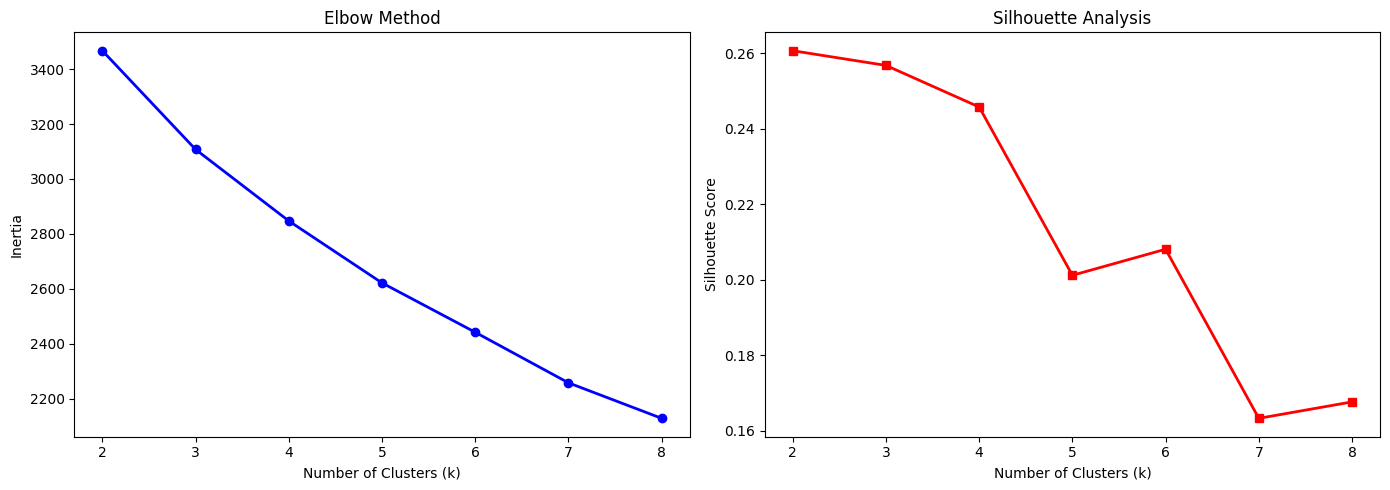


k  | Inertia    | Silhouette
-----------------------------------
2  |    3466.9  | 0.2606
3  |    3107.3  | 0.2567
4  |    2846.9  | 0.2457
5  |    2621.2  | 0.2011
6  |    2441.5  | 0.2080
7  |    2257.4  | 0.1633
8  |    2128.0  | 0.1676


In [5]:
# --- 2.4 Optimal k selection ---
k_range = range(2, 9)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(k_range, inertias, 'bo-', linewidth=2)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.set_xticks(list(k_range))

ax2.plot(k_range, sil_scores, 'rs-', linewidth=2)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.set_xticks(list(k_range))

plt.tight_layout()
plt.show()

print("\nk  | Inertia    | Silhouette")
print("-" * 35)
for k, inr, sil in zip(k_range, inertias, sil_scores):
    print(f"{k}  | {inr:>9.1f}  | {sil:.4f}")

Cluster distribution:
cluster
0    104
1    207
2    439
Name: count, dtype: int64

Cluster Profiles (raw means):
cluster                            0             1             2
total_revenue           4.533010e+06  4.026528e+06  1.107373e+07
avg_order_value         4.884315e+03  4.640692e+03  6.434146e+03
rejection_rate          3.421380e-01  1.981988e-01  2.425826e-01
completion_rate         1.679094e-01  2.787414e-01  2.526350e-01
avg_claim_latency_days  7.195537e+02  7.299430e+02  7.293545e+02
claim_rate              4.633096e-03  5.433384e-03  5.270753e-03


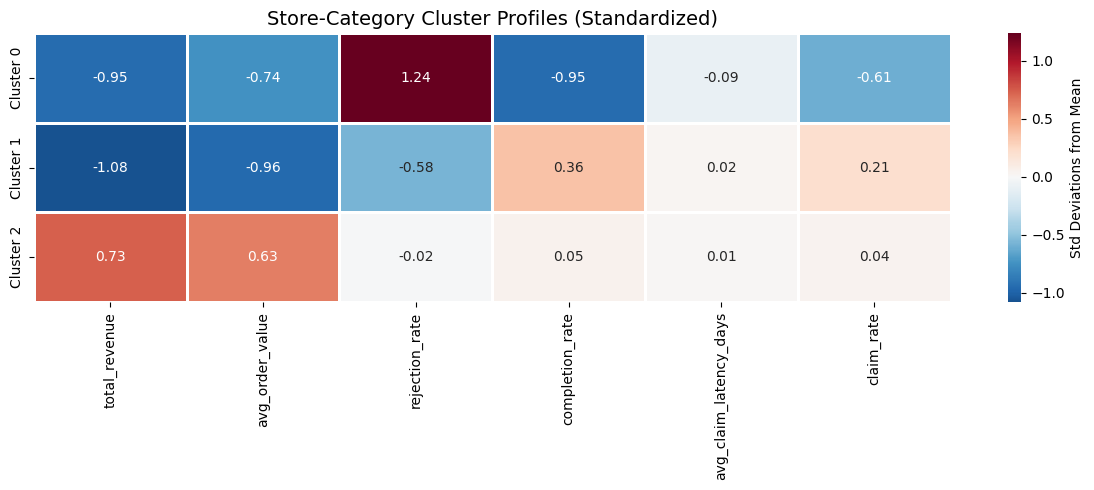


Category breakdown per cluster:
cluster                   0      1      2
category_name                            
Accessories           0.010  0.000  0.169
Audio                 0.010  0.000  0.169
Desktop               0.202  0.261  0.000
Laptop                0.019  0.000  0.166
Smart Speaker         0.202  0.261  0.000
Smartphone            0.019  0.000  0.166
Streaming Device      0.269  0.227  0.000
Subscription Service  0.221  0.251  0.000
Tablet                0.000  0.000  0.171
Wearable              0.048  0.000  0.159


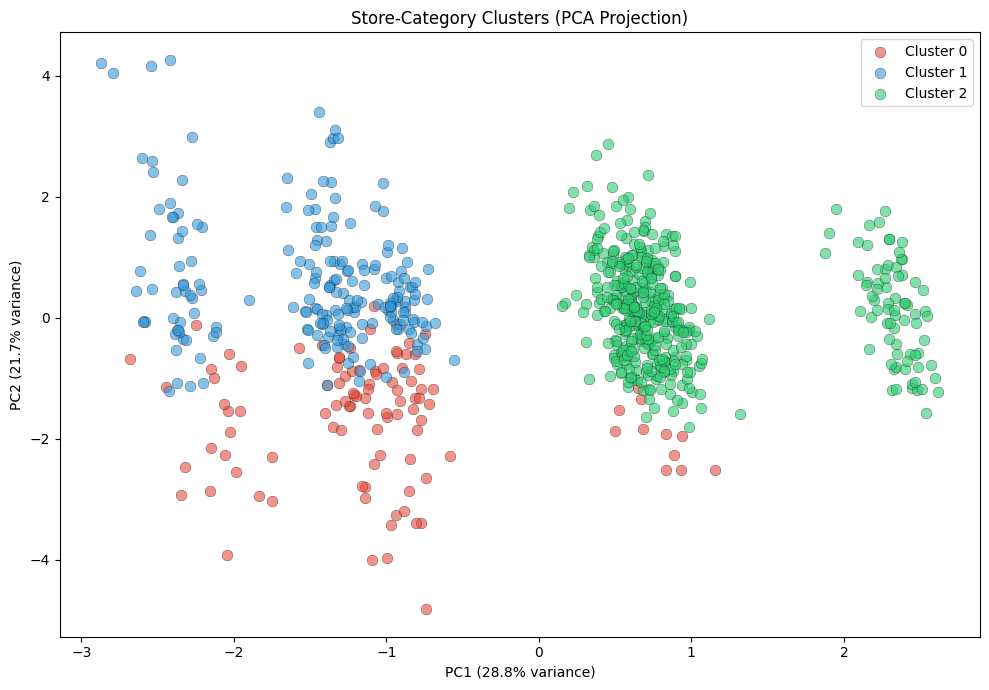

In [6]:
# --- 2.5 Fit final model (k=3) and profile clusters ---
final_k = 3
km_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
store_cat['cluster'] = km_final.fit_predict(X_scaled)

print("Cluster distribution:")
print(store_cat['cluster'].value_counts().sort_index())

# Cluster profiles
final_features = list(df_feat.columns)
profile = store_cat.groupby('cluster')[final_features].mean()
print("\nCluster Profiles (raw means):")
print(profile.T)

# Heatmap of standardised centroids
centroids_scaled = pd.DataFrame(
    scaler.transform(profile),
    columns=final_features,
    index=[f'Cluster {i}' for i in range(final_k)]
)
plt.figure(figsize=(12, 5))
sns.heatmap(centroids_scaled, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=1, cbar_kws={'label': 'Std Deviations from Mean'})
plt.title('Store-Category Cluster Profiles (Standardized)', fontsize=14)
plt.tight_layout()
plt.show()

# Category breakdown
print("\nCategory breakdown per cluster:")
print(pd.crosstab(store_cat['category_name'], store_cat['cluster'], normalize='columns').round(3))

# PCA visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71']
for c in range(final_k):
    mask = store_cat['cluster'] == c
    plt.scatter(X_pca[mask.values, 0], X_pca[mask.values, 1],
                c=colors[c], label=f'Cluster {c}', s=60, alpha=0.6, edgecolors='black', linewidths=0.3)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Store-Category Clusters (PCA Projection)')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# --- 2.6 Export and merge cluster labels ---
store_cat.to_csv('store_category_clusters.csv', index=False)
print(f"Exported: store_category_clusters.csv ({store_cat.shape[0]} rows)")

cluster_names = {
    0: 'High-Rejection Outliers',
    1: 'Digital Services & Niche Hardware',
    2: 'Core Hardware Revenue Drivers'
}

clusters = store_cat[['store_id', 'category_name', 'cluster']].copy()
clusters['cluster_name'] = clusters['cluster'].map(cluster_names)

df = df.merge(clusters[['store_id', 'category_name', 'cluster', 'cluster_name']],
              on=['store_id', 'category_name'], how='left')
df.to_csv('apple_merged_clustered.csv', index=False)
print(f"Saved: apple_merged_clustered.csv ({df.shape[0]} rows)")

Exported: store_category_clusters.csv (750 rows)
Saved: apple_merged_clustered.csv (1040200 rows)


## Section 3: RFM Analysis for Customer Prioritisation

**Business Question:** How can Apple identify and prioritise high-value customer segments using RFM analysis to optimise retention strategies?

**Method:** Recency-Frequency-Monetary scoring at store-category level with quintile-based segmentation.

**Output:** 6 customer segments:
- **Champions:** Recent, frequent, high-value — protect and maximise LTV
- **Loyal:** Consistent, valuable — nurture long-term relationship
- **New/Promising:** Recent but low frequency — convert to loyal
- **At Risk:** Long inactive but once valuable — win-back campaigns
- **Hibernating:** Inactive, low frequency/value — low priority
- **Need Attention:** Others — segment and strategise

---

In [8]:
# ============================================================
# SECTION 3: RFM ANALYSIS FOR CUSTOMER PRIORITISATION
# ============================================================

# --- 3.1 Data preparation ---
df = pd.read_csv('apple_merged_clustered.csv', low_memory=False)
df['sale_date'] = pd.to_datetime(df['sale_date'])
df['revenue'] = df['price'] * df['quantity']

ref_date = df['sale_date'].max() + pd.Timedelta(days=1)
print(f"Data: {df.shape[0]:,} transactions | {df['store_id'].nunique()} stores")
print(f"Period: {df['sale_date'].min().date()} to {df['sale_date'].max().date()}")
print(f"Reference date: {ref_date.date()}")

# --- 3.2 Compute RFM metrics ---
rfm = df.groupby(['store_id', 'category_name']).agg(
    recency=('sale_date', lambda x: (ref_date - x.max()).days),
    frequency=('sale_id', 'nunique'),
    monetary=('revenue', 'sum')
).reset_index()

print(f"\nRaw RFM metrics ({len(rfm)} obs):")
print(rfm[['recency', 'frequency', 'monetary']].describe().round(1))

# --- 3.3 Quintile-based scoring (1-5) ---
rfm['R_score'] = pd.qcut(rfm['recency'].rank(method='first'), q=5, labels=[5, 4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

for col in ['R_score', 'F_score', 'M_score']:
    rfm[col] = rfm[col].astype(int)

rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']
rfm['RFM_segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
print(f"\nRFM Score distribution:\n{rfm['RFM_score'].describe().round(2)}")

Data: 1,040,200 transactions | 75 stores
Period: 2020-01-01 to 2024-11-12
Reference date: 2024-11-13

Raw RFM metrics (750 obs):
       recency  frequency    monetary
count    750.0      750.0       750.0
mean       2.4     1386.9   8221724.0
std        2.5      577.9   3891568.8
min        1.0      273.0    997666.0
25%        1.0     1084.0   4904743.0
50%        1.0     1538.0   9430511.5
75%        3.0     1713.8  11506335.5
max       28.0     2290.0  13474735.0

RFM Score distribution:
count    750.0
mean       9.0
std        3.4
min        3.0
25%        7.0
50%        9.0
75%       12.0
max       15.0
Name: RFM_score, dtype: float64


In [9]:
# --- 3.4 Segment assignment ---
def assign_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New/Promising'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Hibernating'
    else:
        return 'Need Attention'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

print("Segment distribution:")
seg_dist = rfm['segment'].value_counts()
for seg, count in seg_dist.items():
    print(f"  {seg:<20s} {count:>3d} store-categories ({count/len(rfm)*100:.1f}%)")

# --- 3.5 Add warranty metrics and cluster labels ---
claims = df[df['claim_id'].notna()].copy()
warranty_agg = claims.groupby(['store_id', 'category_name']).agg(
    total_claims=('claim_id', 'count'),
    rejection_rate=('repair_status', lambda x: (x == 'Rejected').mean()),
    completion_rate=('repair_status', lambda x: (x == 'Completed').mean()),
).reset_index()

rfm = rfm.merge(warranty_agg, on=['store_id', 'category_name'], how='left')
rfm['total_claims'] = rfm['total_claims'].fillna(0)
rfm['claim_rate'] = rfm['total_claims'] / rfm['frequency']

store_info = df.groupby(['store_id', 'category_name']).agg(
    store_name=('store_name', 'first'),
    city=('city', 'first'),
    country=('country', 'first'),
    cluster=('cluster', lambda x: x.mode()[0]),
    cluster_name=('cluster_name', 'first'),
).reset_index()

rfm = rfm.merge(store_info, on=['store_id', 'category_name'])
print(f"RFM table: {rfm.shape}")

Segment distribution:
  Loyal                146 store-categories (19.5%)
  Hibernating          140 store-categories (18.7%)
  At Risk              132 store-categories (17.6%)
  Need Attention       125 store-categories (16.7%)
  Champions            119 store-categories (15.9%)
  New/Promising         88 store-categories (11.7%)
RFM table: (750, 20)


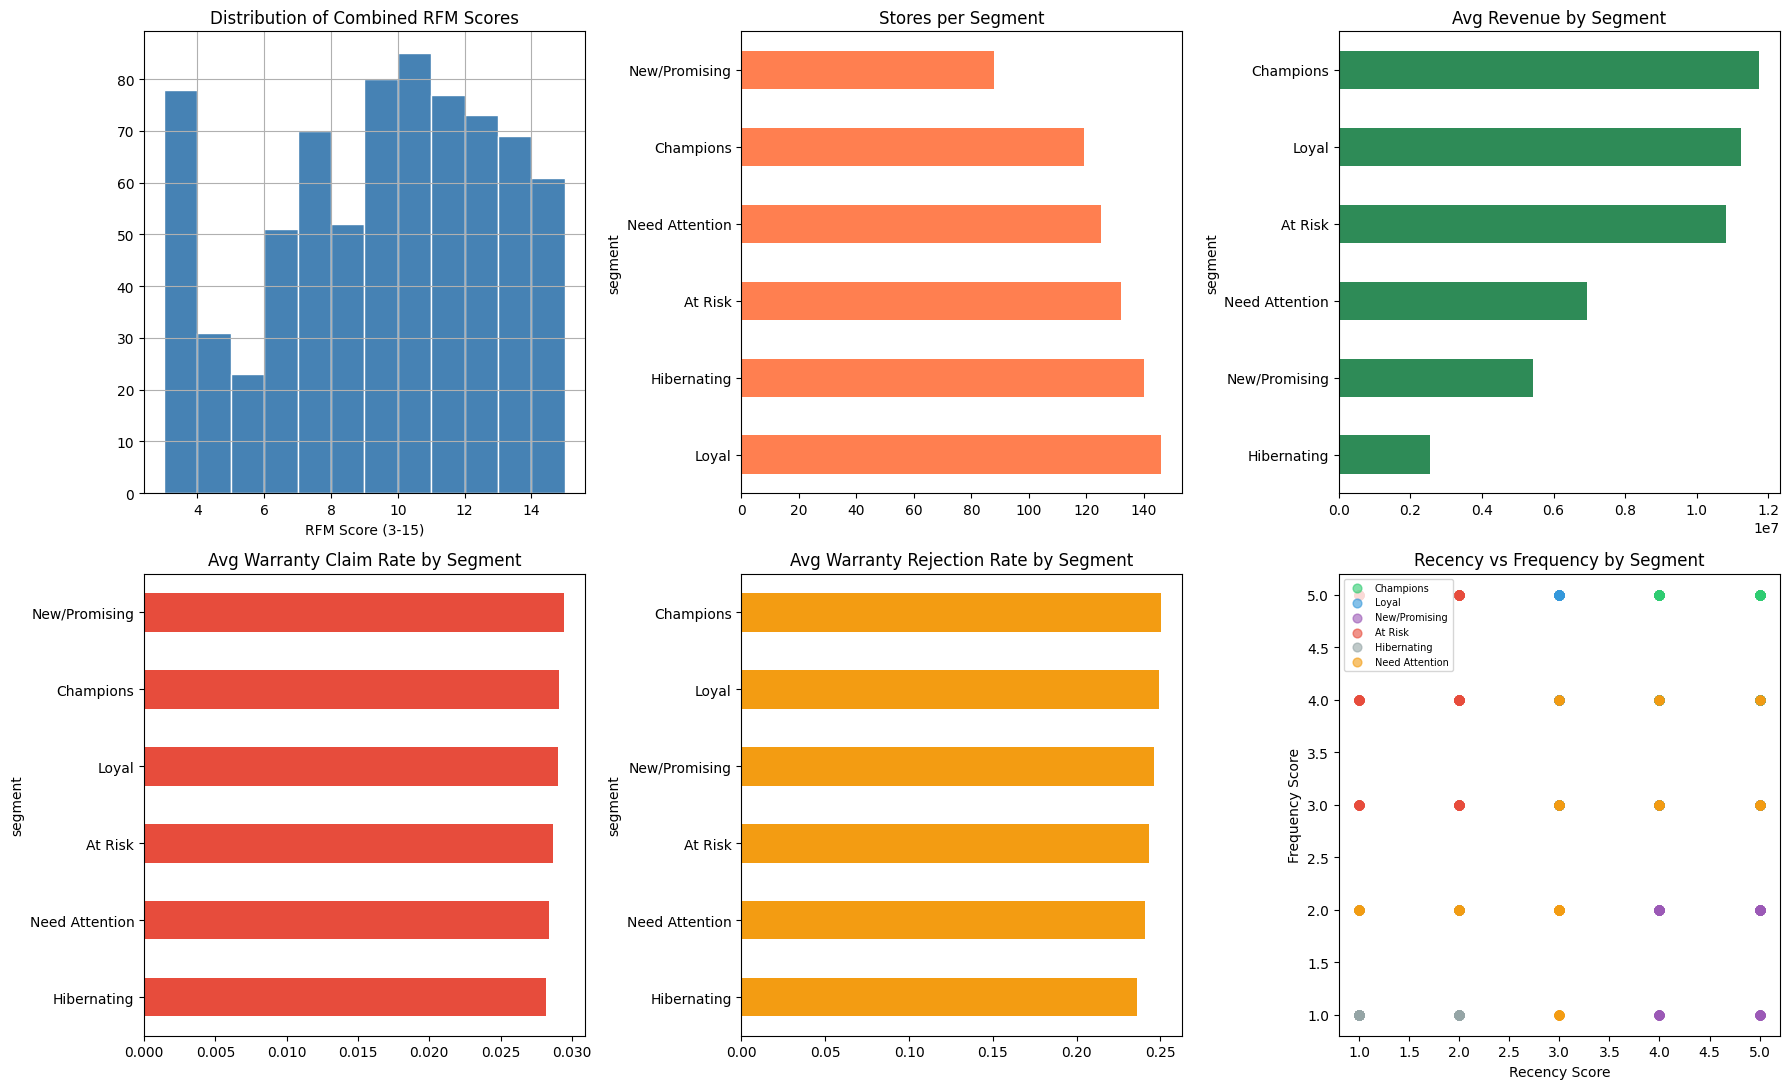

In [10]:
# --- 3.6 Visualisations ---
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

rfm['RFM_score'].hist(bins=12, ax=axes[0, 0], color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribution of Combined RFM Scores')
axes[0, 0].set_xlabel('RFM Score (3-15)')

seg_counts = rfm['segment'].value_counts()
seg_counts.plot.barh(ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Stores per Segment')

rfm.groupby('segment')['monetary'].mean().sort_values().plot.barh(ax=axes[0, 2], color='seagreen')
axes[0, 2].set_title('Avg Revenue by Segment')

rfm.groupby('segment')['claim_rate'].mean().sort_values().plot.barh(ax=axes[1, 0], color='#e74c3c')
axes[1, 0].set_title('Avg Warranty Claim Rate by Segment')

rfm.groupby('segment')['rejection_rate'].mean().sort_values().plot.barh(ax=axes[1, 1], color='#f39c12')
axes[1, 1].set_title('Avg Warranty Rejection Rate by Segment')

colors_map = {'Champions': '#2ecc71', 'Loyal': '#3498db', 'New/Promising': '#9b59b6',
              'At Risk': '#e74c3c', 'Hibernating': '#95a5a6', 'Need Attention': '#f39c12'}
for seg, color in colors_map.items():
    mask = rfm['segment'] == seg
    axes[1, 2].scatter(rfm.loc[mask, 'R_score'], rfm.loc[mask, 'F_score'], c=color, label=seg, s=40, alpha=0.6)
axes[1, 2].set_xlabel('Recency Score')
axes[1, 2].set_ylabel('Frequency Score')
axes[1, 2].set_title('Recency vs Frequency by Segment')
axes[1, 2].legend(fontsize=7)

plt.tight_layout()
plt.show()

SEGMENT PROFILES:
                n_stores  avg_recency  avg_frequency  avg_monetary  avg_claim_rate  avg_rejection_rate  avg_completion_rate  pct_of_stores  revenue_share
segment                                                                                                                                                  
At Risk              132       3.0379      1753.5379  1.082032e+07          0.0287              0.2432               0.2594           17.6           23.2
Champions            119       1.0000      1947.5714  1.173386e+07          0.0291              0.2505               0.2447           15.9           22.6
Hibernating          140       5.4643       539.5500  2.545131e+06          0.0282              0.2358               0.2506           18.7            5.8
Loyal                146       1.2260      1701.9932  1.123544e+07          0.0290              0.2493               0.2485           19.5           26.6
Need Attention       125       1.7680      1332.8480  6.94

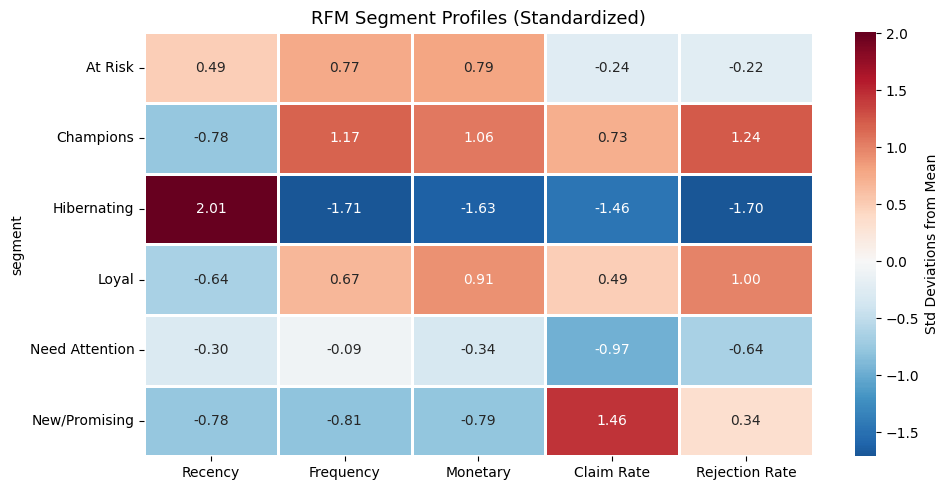


SEGMENT BY CLUSTER:
cluster_name    Core Hardware Revenue Drivers  \
segment                                         
At Risk                                   111   
Champions                                 118   
Hibernating                                 0   
Loyal                                     141   
Need Attention                             38   
New/Promising                              31   

cluster_name    Digital Services & Niche Hardware  High-Rejection Outliers  
segment                                                                     
At Risk                                        14                        7  
Champions                                       0                        1  
Hibernating                                    95                       45  
Loyal                                           0                        5  
Need Attention                                 58                       29  
New/Promising                                  

In [11]:
# --- 3.7 Segment profiles ---
from sklearn.preprocessing import StandardScaler as SS

profile = rfm.groupby('segment').agg(
    n_stores=('store_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    avg_claim_rate=('claim_rate', 'mean'),
    avg_rejection_rate=('rejection_rate', 'mean'),
    avg_completion_rate=('completion_rate', 'mean'),
).round(4)

profile['pct_of_stores'] = (profile['n_stores'] / profile['n_stores'].sum() * 100).round(1)
profile['revenue_share'] = (profile['avg_monetary'] * profile['n_stores'] /
                           (profile['avg_monetary'] * profile['n_stores']).sum() * 100).round(1)

print("SEGMENT PROFILES:")
print(profile.to_string())

# Heatmap
heatmap_cols = ['avg_recency', 'avg_frequency', 'avg_monetary', 'avg_claim_rate', 'avg_rejection_rate']
heatmap_data = profile[heatmap_cols].copy()
heatmap_data.columns = ['Recency', 'Frequency', 'Monetary', 'Claim Rate', 'Rejection Rate']
scaler_h = SS()
heatmap_scaled = pd.DataFrame(scaler_h.fit_transform(heatmap_data),
                              index=heatmap_data.index, columns=heatmap_data.columns)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_scaled, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=1, cbar_kws={'label': 'Std Deviations from Mean'}, ax=ax)
ax.set_title('RFM Segment Profiles (Standardized)', fontsize=13)
plt.tight_layout()
plt.show()

# Segment x Cluster
print("\nSEGMENT BY CLUSTER:")
print(pd.crosstab(rfm['segment'], rfm['cluster_name']))

## Section 4: Cojoint Analysis for Product and Pricing Decision

**Business Question**: Which combination of product attributes (category, sub-brand, price point) drives the most demand, and does this vary across store clusters?

- The purpose of this is to estimate which product attribute combinations (category, sub-brand, price tier) drive the most demand. This answers pricing and portfolio questions: Which attributes do customers value most? Does a MacBook Pro at \$1,300 cannibalize MacBook Air at \$1,800? Are buyers more price-sensitive in Audio than Laptops? The insights guide product line decisions, pricing strategy, and help identify gaps or overlaps in the portfolio.
Method Type: Revealed Preference Conjoint (not survey-based).

- Traditional conjoint uses designed experiments with hypothetical product profiles. Since we lack survey data, we use observed purchase behavior to infer attribute preferences. This is sometimes called "hedonic regression" or "revealed preference estimation."

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# PHASE 1: DATA PREPARATION
# Spec ref: Section 4, Phase 1
# ============================================================

# --- 1.1 Load data ---
df = pd.read_csv('apple_merged_clustered.csv', low_memory=False,
                  parse_dates=['sale_date', 'launch_date'])

print(f"Raw data: {df.shape[0]:,} rows, {df.shape[1]} cols")

# --- 1.2 Extract sub-brand from product_name ---
# Logic: take name before parenthetical, strip generation/size suffixes
def extract_sub_brand(name):
    # Remove parenthetical details like "(M2)", "(2nd Generation)", "(Touch Bar)"
    base = name.split('(')[0].strip()
    # Remove inch specifications
    for suffix in ['12.9-inch', '11-inch', '13-inch', '14-inch', '16-inch', '24-inch', '27-inch']:
        base = base.replace(suffix, '').strip()
    return base

df['sub_brand'] = df['product_name'].apply(extract_sub_brand)
print(f"\nUnique sub-brands extracted: {df['sub_brand'].nunique()}")
print("Sub-brands per category:")
for cat in sorted(df['category_name'].unique()):
    brands = sorted(df[df['category_name'] == cat]['sub_brand'].unique())
    print(f"  {cat}: {brands}")

# --- 1.3 Compute product age at time of sale ---
df['product_age_days'] = (df['sale_date'] - df['launch_date']).dt.days

# --- 1.4 Create price tiers ---
df['price_tier'] = pd.qcut(df['price'], q=4, labels=['Low', 'Mid', 'High', 'Premium'])
tier_edges = pd.qcut(df['price'], q=4, retbins=True)[1]
print(f"\nPrice tier edges: {[round(e) for e in tier_edges]}")

df.head()

# --- 1.5 Aggregate to Product-Store level (Spec: Option B) ---
# Each row = one product in one store, with total quantity sold
df_conjoint = df.groupby(['product_id', 'store_id']).agg(
    total_quantity=('quantity', 'sum'),
    category_name=('category_name', 'first'),
    sub_brand=('sub_brand', 'first'),
    price=('price', 'first'),
    price_tier=('price_tier', 'first'),
    product_age_days=('product_age_days', 'mean'),  # avg age across sales
    cluster=('cluster', lambda x: x.mode()[0]),      # most common cluster for this product-store
    cluster_name=('cluster_name', 'first'),
).reset_index()

# Log-transform quantity (dependent variable)
df_conjoint['ln_quantity'] = np.log(df_conjoint['total_quantity'])

print(f"\nConjoint table: {df_conjoint.shape[0]:,} rows (product x store)")
print(f"Nulls: {df_conjoint.isnull().sum().sum()}")

# --- 1.6 Validation ---
print(f"\nQuantity distribution:")
print(df_conjoint['total_quantity'].describe().round(1))
print(f"\nln(quantity) distribution:")
print(df_conjoint['ln_quantity'].describe().round(3))

Raw data: 1,040,200 rows, 20 cols

Unique sub-brands extracted: 67
Sub-brands per category:
  Accessories: ['AirTag', 'Apple Pencil', 'Leather Case for iPhone', 'Lightning to USB Cable', 'MagSafe Battery Pack', 'MagSafe Charger', 'Magic Keyboard', 'Magic Keyboard with Touch ID', 'Magic Mouse', 'Magic Trackpad', 'Silicone Case for iPhone', 'Smart Cover for iPad', 'Smart Keyboard Folio']
  Audio: ['AirPods', 'AirPods Max', 'AirPods Pro', 'Beats Fit Pro', 'Beats Powerbeats Pro', 'Beats Solo Pro', 'Beats Studio Buds', 'HomePod', 'HomePod mini']
  Desktop: ['Mac Mini', 'Mac Pro', 'Mac Studio', 'iMac', 'iMac Pro', 'iMac with Retina Display']
  Laptop: ['MacBook', 'MacBook Air', 'MacBook Pro']
  Smart Speaker: ['HomePod', 'HomePod mini']
  Smartphone: ['iPhone 12', 'iPhone 12 Pro', 'iPhone 12 Pro Max', 'iPhone 12 mini', 'iPhone 13', 'iPhone 13 Pro', 'iPhone 13 Pro Max', 'iPhone 13 mini', 'iPhone 14', 'iPhone 14 Plus', 'iPhone 14 Pro', 'iPhone 14 Pro Max', 'iPhone SE']
  Streaming Device: ['Ap

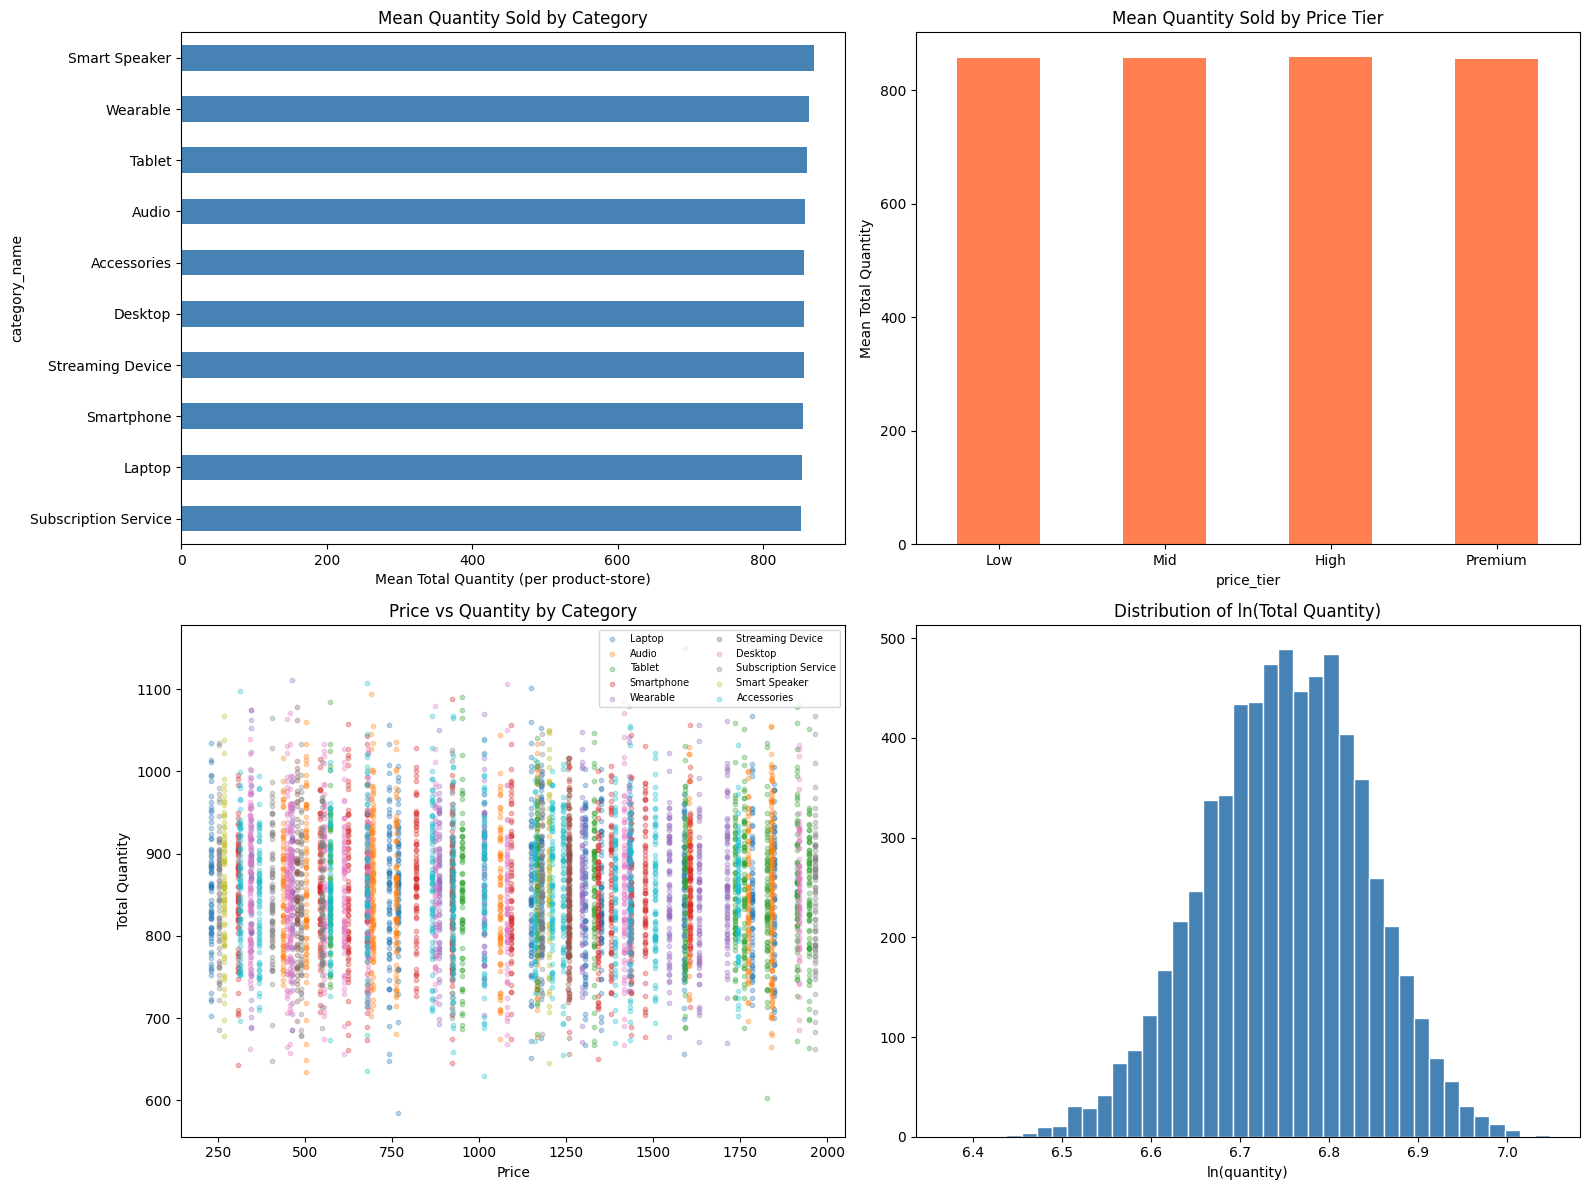

Phase 2 plots saved.

Bottom 5 sub-brands by demand:
sub_brand
iPhone 12 Pro           836.960000
iMac Pro                837.200000
Apple One               838.986667
Apple Watch Series 8    844.080000
Magic Keyboard          844.586667
Name: total_quantity, dtype: float64

Top 5 sub-brands by demand:
sub_brand
iMac with Retina Display    870.026667
HomePod                     871.973333
iPhone 13 Pro Max           872.866667
Apple Watch Series 9        873.080000
Apple Watch Series 7        876.520000
Name: total_quantity, dtype: float64


In [13]:
# ============================================================
# PHASE 2: EXPLORATORY ANALYSIS
# Spec ref: Section 4, Phase 2
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 2.1 Mean quantity by category
cat_demand = df_conjoint.groupby('category_name')['total_quantity'].mean().sort_values()
cat_demand.plot.barh(ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Mean Quantity Sold by Category')
axes[0, 0].set_xlabel('Mean Total Quantity (per product-store)')

# 2.2 Mean quantity by price tier
tier_demand = df_conjoint.groupby('price_tier', observed=True)['total_quantity'].mean()
tier_demand.plot.bar(ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Mean Quantity Sold by Price Tier')
axes[0, 1].set_ylabel('Mean Total Quantity')
axes[0, 1].tick_params(axis='x', rotation=0)

# 2.3 Price vs Quantity scatter by category
for cat in df_conjoint['category_name'].unique():
    mask = df_conjoint['category_name'] == cat
    axes[1, 0].scatter(df_conjoint.loc[mask, 'price'],
                       df_conjoint.loc[mask, 'total_quantity'],
                       alpha=0.3, s=10, label=cat)
axes[1, 0].set_xlabel('Price')
axes[1, 0].set_ylabel('Total Quantity')
axes[1, 0].set_title('Price vs Quantity by Category')
axes[1, 0].legend(fontsize=7, loc='upper right', ncol=2)

# 2.4 Distribution of ln(quantity)
axes[1, 1].hist(df_conjoint['ln_quantity'], bins=40, color='steelblue', edgecolor='white')
axes[1, 1].set_title('Distribution of ln(Total Quantity)')
axes[1, 1].set_xlabel('ln(quantity)')

plt.tight_layout()
plt.savefig('phase2_exploratory.png', dpi=150, bbox_inches='tight')
plt.show()
print("Phase 2 plots saved.")

# Top/bottom sub-brands by demand
sub_demand = df_conjoint.groupby('sub_brand')['total_quantity'].mean().sort_values()
print("\nBottom 5 sub-brands by demand:")
print(sub_demand.head())
print("\nTop 5 sub-brands by demand:")
print(sub_demand.tail())

In [14]:
# ============================================================
# PHASE 3: BASE CONJOINT MODEL
# Spec ref: Section 4, Phase 3
# Model: ln(quantity) = β₀ + β(category) + β(price) + β(product_age) + ε
# ============================================================

# --- 3.1 Encode variables ---
# Category dummies (reference = most common category for interpretability)
cat_dummies = pd.get_dummies(df_conjoint['category_name'], prefix='cat', drop_first=True, dtype=int)

# Sub-brand dummies — collapse rare sub-brands (< 50 obs) into "Other"
brand_counts = df_conjoint['sub_brand'].value_counts()
rare_brands = brand_counts[brand_counts < 50].index
df_conjoint['sub_brand_clean'] = df_conjoint['sub_brand'].replace(rare_brands, 'Other')
brand_dummies = pd.get_dummies(df_conjoint['sub_brand_clean'], prefix='brand', drop_first=True, dtype=int)

# --- 3.2 Assemble feature matrix ---
X = pd.concat([cat_dummies, brand_dummies], axis=1)
X['price'] = df_conjoint['price']
X['product_age_days'] = df_conjoint['product_age_days']
X = sm.add_constant(X)

y = df_conjoint['ln_quantity']

# --- 3.3 Fit OLS with robust standard errors (HC3) ---
model_base = sm.OLS(y, X).fit(cov_type='HC3')

print("\n" + "=" * 60)
print("BASE CONJOINT MODEL (OLS)")
print("=" * 60)
print(f"R² = {model_base.rsquared:.4f}")
print(f"Adj R² = {model_base.rsquared_adj:.4f}")
print(f"F-stat = {model_base.fvalue:.1f} (p = {model_base.f_pvalue:.2e})")
print(f"Observations = {model_base.nobs:.0f}")
print(model_base.summary2().tables[1].to_string())

# --- 3.4 Extract and rank part-worths ---
# Category part-worths (coefficients on category dummies)
cat_coeffs = model_base.params.filter(like='cat_').sort_values()
cat_pvals = model_base.pvalues.filter(like='cat_')

print("\n\nCATEGORY PART-WORTHS (relative to reference category):")
print("-" * 50)
for name, coeff in cat_coeffs.items():
    sig = "***" if cat_pvals[name] < 0.001 else "**" if cat_pvals[name] < 0.01 else "*" if cat_pvals[name] < 0.05 else ""
    clean_name = name.replace('cat_', '')
    print(f"  {clean_name:30s} {coeff:+.4f} {sig}")

print(f"\n  Price coefficient: {model_base.params['price']:.6f} (p={model_base.pvalues['price']:.4f})")
print(f"  Product age coefficient: {model_base.params['product_age_days']:.6f} (p={model_base.pvalues['product_age_days']:.4f})")


BASE CONJOINT MODEL (OLS)
R² = 0.0100
Adj R² = -0.0004
F-stat = 534606.0 (p = 0.00e+00)
Observations = 6675
                                           Coef.  Std.Err.            z          P>|z|    [0.025    0.975]
const                               6.443488e+00  0.005291  1217.908257   0.000000e+00  6.433118  6.453857
cat_Audio                           3.080937e-01  0.008240    37.388684  5.967488e-306  0.291943  0.324244
cat_Desktop                         2.623853e-01  0.003581    73.272655   0.000000e+00  0.255367  0.269404
cat_Laptop                          2.283660e-01  0.002934    77.834027   0.000000e+00  0.222615  0.234117
cat_Smart Speaker                   3.165498e-01  0.013009    24.332998  8.775391e-131  0.291052  0.342047
cat_Smartphone                      2.847485e-01  0.003106    91.687952   0.000000e+00  0.278662  0.290835
cat_Streaming Device                2.300670e-01  0.004649    49.491540   0.000000e+00  0.220956  0.239178
cat_Subscription Service           


PRICE SENSITIVITY MODEL (Category × Price Interactions)
R² = 0.0028
Adj R² = -0.0002


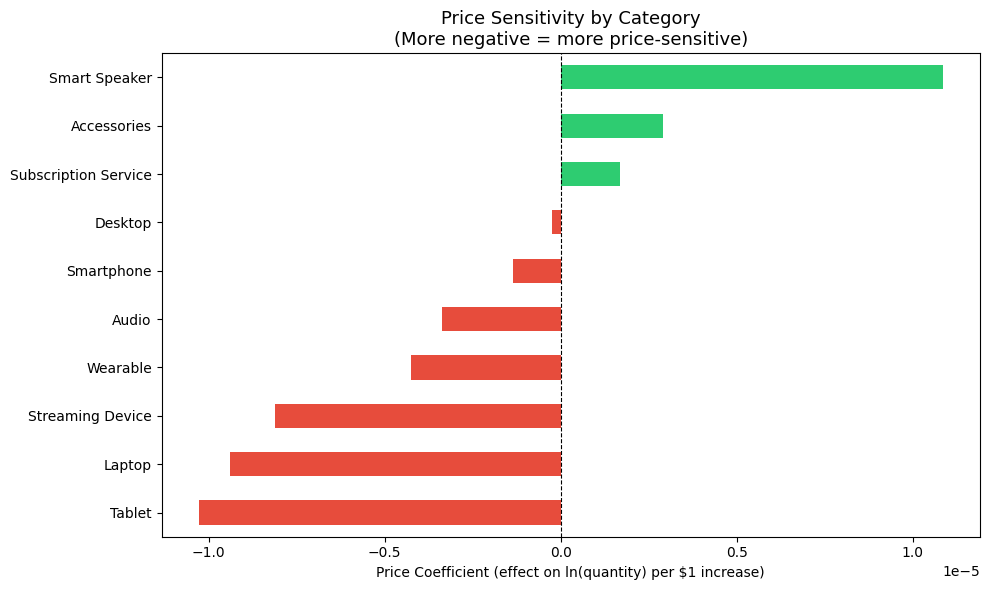


Price Elasticity by Category (coefficient per $1 price increase):
--------------------------------------------------
  Tablet                         -0.000010
  Laptop                         -0.000009
  Streaming Device               -0.000008
  Wearable                       -0.000004
  Audio                          -0.000003
  Smartphone                     -0.000001
  Desktop                        -0.000000
  Subscription Service           +0.000002
  Accessories                    +0.000003
  Smart Speaker                  +0.000011

Estimated demand change from 10% price increase:
--------------------------------------------------
  Tablet                         avg_price=$1480, 10% increase → -0.15% demand change
  Laptop                         avg_price=$1194, 10% increase → -0.11% demand change
  Streaming Device               avg_price=$997, 10% increase → -0.08% demand change
  Wearable                       avg_price=$1147, 10% increase → -0.05% demand change
  Audio 

In [15]:
# ============================================================
# PHASE 4: PRICE SENSITIVITY ANALYSIS
# Spec ref: Section 4, Phase 4
# Model: ln(quantity) = β₀ + β(category) + β(price) + β(category × price) + controls
# ============================================================

# --- 4.1 Create category-price interactions ---
X_interact = pd.concat([cat_dummies], axis=1).copy()
X_interact['price'] = df_conjoint['price']
X_interact['product_age_days'] = df_conjoint['product_age_days']

# Interaction terms: each category × price
for col in cat_dummies.columns:
    X_interact[f'{col}_x_price'] = cat_dummies[col] * df_conjoint['price']

X_interact = sm.add_constant(X_interact)

# --- 4.2 Fit interaction model ---
model_interact = sm.OLS(y, X_interact).fit(cov_type='HC3')

print("\n" + "=" * 60)
print("PRICE SENSITIVITY MODEL (Category × Price Interactions)")
print("=" * 60)
print(f"R² = {model_interact.rsquared:.4f}")
print(f"Adj R² = {model_interact.rsquared_adj:.4f}")

# --- 4.3 Extract price elasticities by category ---
# Base price effect = coefficient on 'price'
# Category-specific effect = base + interaction coefficient
base_price = model_interact.params['price']
ref_category = [c for c in df_conjoint['category_name'].unique() if f'cat_{c}' not in cat_dummies.columns][0]

elasticities = {ref_category: base_price}
for col in cat_dummies.columns:
    interact_col = f'{col}_x_price'
    cat_name = col.replace('cat_', '')
    elasticities[cat_name] = base_price + model_interact.params.get(interact_col, 0)

elasticity_df = pd.Series(elasticities).sort_values()

# --- 4.4 Visualize ---
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in elasticity_df.values]
elasticity_df.plot.barh(ax=ax, color=colors)
ax.set_title('Price Sensitivity by Category\n(More negative = more price-sensitive)', fontsize=13)
ax.set_xlabel('Price Coefficient (effect on ln(quantity) per $1 increase)')
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('phase4_price_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPrice Elasticity by Category (coefficient per $1 price increase):")
print("-" * 50)
for cat, elast in elasticity_df.items():
    print(f"  {cat:30s} {elast:+.6f}")

# Demand impact of 10% price increase per category
print("\nEstimated demand change from 10% price increase:")
print("-" * 50)
for cat in elasticity_df.index:
    avg_price = df_conjoint[df_conjoint['category_name'] == cat]['price'].mean()
    price_increase = avg_price * 0.10
    demand_change = elasticity_df[cat] * price_increase * 100  # % change
    print(f"  {cat:30s} avg_price=${avg_price:.0f}, 10% increase → {demand_change:+.2f}% demand change")


CLUSTER-LEVEL CONJOINT ANALYSIS

--- Cluster 0: High-Rejection Outliers (613 obs) ---
R² = 0.0211, Price coeff = -0.000008

--- Cluster 1: Digital Services & Niche (1153 obs) ---
R² = 0.0049, Price coeff = 0.000005

--- Cluster 2: Core Hardware Drivers (4909 obs) ---
R² = 0.0014, Price coeff = -0.000004


Price Sensitivity Comparison Across Clusters:
------------------------------------------------------------
  Cluster 0 (High-Rejection Outliers       ): -0.000008 ns
  Cluster 1 (Digital Services & Niche      ): +0.000005 ns
  Cluster 2 (Core Hardware Drivers         ): -0.000004 ns


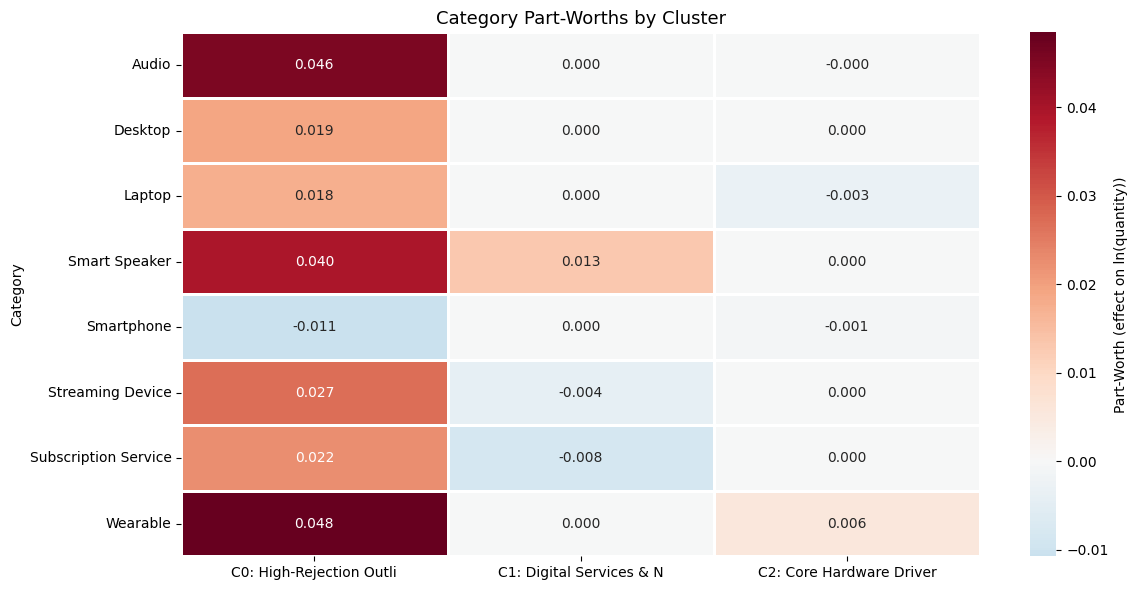

In [16]:
# ============================================================
# PHASE 5: CLUSTER-LEVEL CONJOINT
# Spec ref: Section 4, Phase 5
# Split model by cluster to test if preferences vary by segment
# ============================================================

print("\n" + "=" * 60)
print("CLUSTER-LEVEL CONJOINT ANALYSIS")
print("=" * 60)

cluster_names = {0: 'High-Rejection Outliers', 1: 'Digital Services & Niche', 2: 'Core Hardware Drivers'}
cluster_results = {}

for cluster_id in sorted(df_conjoint['cluster'].unique()):
    subset = df_conjoint[df_conjoint['cluster'] == cluster_id]

    # Re-encode for subset (some dummies may be zero)
    X_sub = pd.get_dummies(subset['category_name'], prefix='cat', drop_first=True, dtype=int)
    X_sub['price'] = subset['price'].values
    X_sub['product_age_days'] = subset['product_age_days'].values
    X_sub = sm.add_constant(X_sub)
    y_sub = subset['ln_quantity'].values

    model_sub = sm.OLS(y_sub, X_sub).fit(cov_type='HC3')
    cluster_results[cluster_id] = model_sub

    print(f"\n--- Cluster {cluster_id}: {cluster_names[cluster_id]} ({len(subset)} obs) ---")
    print(f"R² = {model_sub.rsquared:.4f}, Price coeff = {model_sub.params['price']:.6f}")

# --- 5.1 Compare price coefficients across clusters ---
print("\n\nPrice Sensitivity Comparison Across Clusters:")
print("-" * 60)
for cid, model in cluster_results.items():
    p = model.params['price']
    pval = model.pvalues['price']
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
    print(f"  Cluster {cid} ({cluster_names[cid]:30s}): {p:+.6f} {sig}")

# --- 5.2 Heatmap of category part-worths by cluster ---
# Collect category coefficients across clusters
cat_cols = [c for c in cluster_results[0].params.index if c.startswith('cat_')]
heatmap_data = pd.DataFrame(index=[c.replace('cat_', '') for c in cat_cols],
                            columns=[f"C{k}: {cluster_names[k][:20]}" for k in cluster_results])

for cid, model in cluster_results.items():
    col_name = f"C{cid}: {cluster_names[cid][:20]}"
    for cat_col in cat_cols:
        cat_name = cat_col.replace('cat_', '')
        if cat_col in model.params:
            heatmap_data.loc[cat_name, col_name] = model.params[cat_col]
        else:
            heatmap_data.loc[cat_name, col_name] = 0.0

heatmap_data = heatmap_data.astype(float)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            linewidths=1, cbar_kws={'label': 'Part-Worth (effect on ln(quantity))'}, ax=ax)
ax.set_title('Category Part-Worths by Cluster', fontsize=13)
ax.set_ylabel('Category')
plt.tight_layout()
plt.savefig('phase5_cluster_partworts.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ============================================================
# PHASE 6: SUMMARY AND RECOMMENDATIONS
# Spec ref: Section 4, Phase 6
# ============================================================

print("\n" + "=" * 60)
print("CONJOINT ANALYSIS SUMMARY")
print("=" * 60)

# Part-worth ranking
print("\n1. CATEGORY PART-WORTH RANKING (Base Model):")
for i, (name, val) in enumerate(cat_coeffs.sort_values(ascending=False).items(), 1):
    clean = name.replace('cat_', '')
    direction = "↑ demand" if val > 0 else "↓ demand"
    print(f"   {i}. {clean:30s} {val:+.4f} ({direction})")

# Price sensitivity summary
print("\n2. PRICE SENSITIVITY RANKING (most to least sensitive):")
for i, (cat, val) in enumerate(elasticity_df.items(), 1):
    sensitivity = "High" if val < elasticity_df.median() else "Low"
    print(f"   {i}. {cat:30s} {val:+.6f} [{sensitivity}]")

# Cluster differences
print("\n3. CLUSTER DIFFERENCES:")
for cid in cluster_results:
    p = cluster_results[cid].params['price']
    print(f"   Cluster {cid} ({cluster_names[cid]}): price sensitivity = {p:+.6f}")

# Recommendation table
print("\n4. RECOMMENDATION TABLE:")
print(f"   {'Category':<25} {'Part-Worth':>12} {'Price Sens.':>12} {'Action'}")
print("   " + "-" * 75)

for cat in sorted(df_conjoint['category_name'].unique()):
    pw_col = f'cat_{cat}'
    pw = cat_coeffs.get(pw_col, 0.0)
    ps = elasticity_df.get(cat, 0.0)

    if pw > 0 and abs(ps) < abs(elasticity_df.median()):
        action = "Premium pricing opportunity"
    elif pw > 0 and abs(ps) >= abs(elasticity_df.median()):
        action = "High demand but price-sensitive — compete on value"
    elif pw <= 0 and abs(ps) < abs(elasticity_df.median()):
        action = "Low demand, low sensitivity — niche premium"
    else:
        action = "Underperforming — review portfolio"

    print(f"   {cat:<25} {pw:>+12.4f} {ps:>+12.6f} {action}")

print("\n5. MODEL QUALITY:")
print(f"   Base model R² = {model_base.rsquared:.4f}")
print(f"   Interaction model R² = {model_interact.rsquared:.4f}")
print(f"   Key limitation: Revealed preference, not experimental conjoint.")
print(f"   Price is set by Apple (not random), so causal claims are limited.")
print("\n✓ Conjoint analysis complete. Plots saved to working directory.")


CONJOINT ANALYSIS SUMMARY

1. CATEGORY PART-WORTH RANKING (Base Model):
   1. Smart Speaker                  +0.3165 (↑ demand)
   2. Audio                          +0.3081 (↑ demand)
   3. Smartphone                     +0.2847 (↑ demand)
   4. Wearable                       +0.2838 (↑ demand)
   5. Subscription Service           +0.2639 (↑ demand)
   6. Desktop                        +0.2624 (↑ demand)
   7. Tablet                         +0.2503 (↑ demand)
   8. Streaming Device               +0.2301 (↑ demand)
   9. Laptop                         +0.2284 (↑ demand)

2. PRICE SENSITIVITY RANKING (most to least sensitive):
   1. Tablet                         -0.000010 [High]
   2. Laptop                         -0.000009 [High]
   3. Streaming Device               -0.000008 [High]
   4. Wearable                       -0.000004 [High]
   5. Audio                          -0.000003 [High]
   6. Smartphone                     -0.000001 [Low]
   7. Desktop                        -0.000

## Section 5: Logistic Regression for Warranty Claim Risk

**Business Question:** Which store-category-month combinations are most likely to experience high warranty-claim risk?

**Method:** Binary logistic regression on store-category-month aggregates. Target: Top 25% claim rate = high risk.

**Output:**
- ROC-AUC model performance
- Key drivers of warranty claim risk
- Risk profiles by cluster and category
- Actionable thresholds for operational intervention

---

In [18]:
# ============================================================
# SECTION 5: LOGISTIC REGRESSION FOR WARRANTY CLAIM RISK
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

# --- 5.1 Data preparation ---
df = pd.read_csv("apple_merged_clustered.csv", low_memory=False)

# Convert date columns
df["sale_date"] = pd.to_datetime(df["sale_date"], errors="coerce")
df["launch_date"] = pd.to_datetime(df["launch_date"], errors="coerce")
df["claim_date"] = pd.to_datetime(df["claim_date"], errors="coerce")

# Create engineered variables
df["revenue"] = df["quantity"] * df["price"]
df["had_claim"] = df["claim_id"].notna().astype(int)
df["product_age_days"] = (df["sale_date"] - df["launch_date"]).dt.days
df["sale_month"] = df["sale_date"].dt.to_period("M").astype(str)

# --- 5.2 Aggregate to store-category-month level ---
agg = df.groupby(
    ["store_id", "category_name", "country", "cluster_name", "sale_month"],
    as_index=False
).agg(
    total_quantity=("quantity", "sum"),
    avg_price=("price", "mean"),
    total_revenue=("revenue", "sum"),
    avg_product_age_days=("product_age_days", "mean"),
    transactions=("sale_id", "count"),
    claims=("had_claim", "sum")
)

agg["claim_rate"] = agg["claims"] / agg["transactions"]

# Define binary target: top 25% claim-rate groups = high claim risk
threshold = agg["claim_rate"].quantile(0.75)
agg["high_claim_risk"] = (agg["claim_rate"] >= threshold).astype(int)

print("Threshold for high claim risk:", round(threshold, 4))
print("\nClass balance:")
print(agg["high_claim_risk"].value_counts(normalize=True))

Threshold for high claim risk: 0.0435

Class balance:
high_claim_risk
0    0.737284
1    0.262716
Name: proportion, dtype: float64


In [19]:
# --- 5.3 Feature selection and split ---
features = [
    "total_quantity",
    "avg_price",
    "total_revenue",
    "avg_product_age_days",
    "transactions",
    "category_name",
    "country",
    "cluster_name",
    "sale_month"
]

target = "high_claim_risk"

X = agg[features]
y = agg[target]

numeric_features = [
    "total_quantity",
    "avg_price",
    "total_revenue",
    "avg_product_age_days",
    "transactions"
]

categorical_features = [
    "category_name",
    "country",
    "cluster_name",
    "sale_month"
]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --- 5.4 Preprocessing pipelines ---
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# --- 5.5 Logistic regression pipeline ---
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Fit model
log_reg.fit(X_train, y_train)

# --- 5.6 Predictions and evaluation ---
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

print("\nROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


ROC-AUC Score: 0.573

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.47      0.59      6520
           1       0.29      0.62      0.40      2323

    accuracy                           0.51      8843
   macro avg       0.54      0.54      0.49      8843
weighted avg       0.65      0.51      0.54      8843



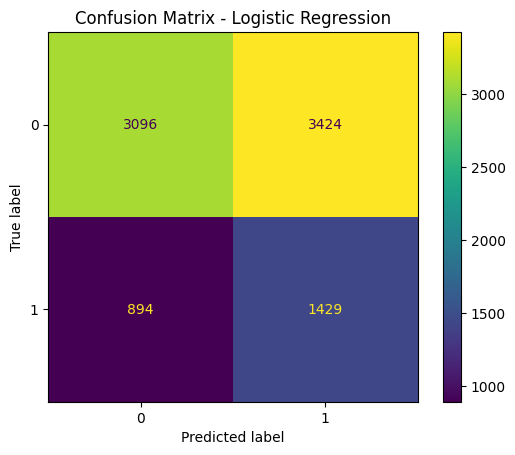

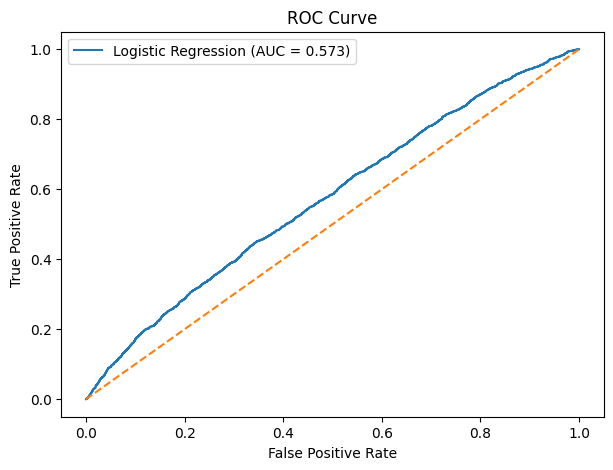


Top positive drivers of high claim risk:
                                            feature  coefficient  odds_ratio
12          cat__category_name_Subscription Service     0.646133    1.908148
7                        cat__category_name_Desktop     0.283391    1.327624
34  cat__cluster_name_Core Hardware Revenue Drivers     0.213886    1.238482
0                               num__total_quantity     0.200231    1.221685
16                             cat__country_Austria     0.178470    1.195386
73                          cat__sale_month_2023-01     0.170844    1.186306
41                          cat__sale_month_2020-05     0.161961    1.175815
82                          cat__sale_month_2023-10     0.145950    1.157138
69                          cat__sale_month_2022-09     0.140894    1.151302
5                    cat__category_name_Accessories     0.140787    1.151179
70                          cat__sale_month_2022-10     0.135163    1.144723
85                          cat__s

In [20]:
# --- 5.7 Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# --- 5.8 ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# --- 5.9 Coefficient Interpretation ---
feature_names = log_reg.named_steps["preprocessor"].get_feature_names_out()
coefficients = log_reg.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "odds_ratio": np.exp(coefficients)
})

print("\nTop positive drivers of high claim risk:")
print(coef_df.sort_values(by="coefficient", ascending=False).head(15))

print("\nTop negative drivers of high claim risk:")
print(coef_df.sort_values(by="coefficient", ascending=True).head(15))

# --- 5.10 Risk summary by cluster and category ---
risk_summary = agg.groupby(["cluster_name", "category_name"], as_index=False).agg(
    avg_claim_rate=("claim_rate", "mean"),
    total_transactions=("transactions", "sum"),
    total_claims=("claims", "sum")
).sort_values("avg_claim_rate", ascending=False)

print("\nRisk summary by cluster and category:")
print(risk_summary.head(15))

## Section 6: Sales Forecasting for Future Demand

**Business Question:** Where is demand headed in the next six months across clusters and categories?

**Method:** Holt-Winters Exponential Smoothing on monthly revenue series with adaptive model selection (Naive vs ES).

**Output:**
- 6-month forecasts for top revenue-generating cluster-category combinations
- Model evaluation metrics (MAE, RMSE, MAPE)
- Forecast vs historical comparison
- New product sales performance tracking

---

In [21]:
# ============================================================
# SECTION 6: SALES FORECASTING
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# --- 6.1 Load and prepare data ---
df = pd.read_csv("apple_merged_clustered.csv", low_memory=False)

# Convert dates
df["sale_date"] = pd.to_datetime(df["sale_date"], errors="coerce")
df["launch_date"] = pd.to_datetime(df["launch_date"], errors="coerce")

# Create revenue
df["revenue"] = df["quantity"] * df["price"]

# Create month variable
df["sale_month"] = df["sale_date"].dt.to_period("M").dt.to_timestamp()

# Product age at sale
df["product_age_days"] = (df["sale_date"] - df["launch_date"]).dt.days

print("Date range:", df["sale_date"].min(), "to", df["sale_date"].max())
print("Rows:", len(df))
print("Clusters:", df["cluster_name"].nunique())
print("Categories:", df["category_name"].nunique())

# --- 6.2 Aggregate monthly sales ---
monthly = (
    df.groupby(["sale_month", "cluster_name", "category_name"], as_index=False)
      .agg(
          total_quantity=("quantity", "sum"),
          total_revenue=("revenue", "sum"),
          avg_price=("price", "mean"),
          transactions=("sale_id", "count")
      )
      .sort_values("sale_month")
)

print("\nMonthly aggregated sample:")
print(monthly.head())

# --- 6.3 Select strongest series ---
series_summary = (
    monthly.groupby(["cluster_name", "category_name"], as_index=False)
    .agg(
        total_revenue=("total_revenue", "sum"),
        months_observed=("sale_month", "nunique"),
        avg_monthly_revenue=("total_revenue", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

# Keep combinations with enough history
series_summary = series_summary[series_summary["months_observed"] >= 18].copy()

# Select top 6 by total revenue
top_series = series_summary.head(6).copy()

print("\nTop series selected for forecasting:")
print(top_series)

Date range: 2020-01-01 00:00:00 to 2024-11-12 00:00:00
Rows: 1040200
Clusters: 3
Categories: 10

Monthly aggregated sample:
   sale_month                   cluster_name         category_name  \
0  2020-01-01  Core Hardware Revenue Drivers           Accessories   
18 2020-01-01        High-Rejection Outliers              Wearable   
17 2020-01-01        High-Rejection Outliers  Subscription Service   
16 2020-01-01        High-Rejection Outliers      Streaming Device   
15 2020-01-01        High-Rejection Outliers            Smartphone   

    total_quantity  total_revenue    avg_price  transactions  
0            15338       15858450  1034.777147          2818  
18             709         837612  1204.487603           121  
17            2487        1981298   806.959276           442  
16            1309        1286142   975.754237           236  
15             309         326436  1099.789474            57  

Top series selected for forecasting:
                    cluster_name catego

In [22]:
# --- 6.4 Define forecasting helpers ---
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def build_monthly_series(data, cluster_name, category_name, target_col="total_revenue"):
    s = data[(data["cluster_name"] == cluster_name) & (data["category_name"] == category_name)].copy()
    s = s[["sale_month", target_col]].sort_values("sale_month")
    s = s.set_index("sale_month").asfreq("MS")
    s[target_col] = s[target_col].fillna(0)
    return s[target_col]

def fit_and_compare_models(ts, forecast_horizon=6, test_horizon=3):
    if len(ts) < (test_horizon + 6):
        return None

    train = ts.iloc[:-test_horizon]
    test = ts.iloc[-test_horizon:]

    # Baseline: Naive forecast
    naive_pred = np.repeat(train.iloc[-1], test_horizon)

    baseline_mae = mean_absolute_error(test, naive_pred)
    baseline_rmse = np.sqrt(mean_squared_error(test, naive_pred))
    baseline_mape = mape(test, naive_pred)

    best_model_name = "Naive"
    best_pred_test = naive_pred
    best_mae = baseline_mae
    best_rmse = baseline_rmse
    best_mape = baseline_mape
    final_forecast = np.repeat(ts.iloc[-1], forecast_horizon)

    # Holt / Holt-Winters
    try:
        if len(train) >= 24:
            hw_model = ExponentialSmoothing(
                train,
                trend="add",
                seasonal="add",
                seasonal_periods=12,
                initialization_method="estimated"
            ).fit()
        else:
            hw_model = ExponentialSmoothing(
                train,
                trend="add",
                seasonal=None,
                initialization_method="estimated"
            ).fit()

        hw_pred = hw_model.forecast(test_horizon)

        hw_mae = mean_absolute_error(test, hw_pred)
        hw_rmse = np.sqrt(mean_squared_error(test, hw_pred))
        hw_mape = mape(test, hw_pred)

        if hw_mae < best_mae:
            best_model_name = "ExponentialSmoothing"
            best_pred_test = hw_pred
            best_mae = hw_mae
            best_rmse = hw_rmse
            best_mape = hw_mape

            if len(ts) >= 24:
                final_model = ExponentialSmoothing(
                    ts,
                    trend="add",
                    seasonal="add",
                    seasonal_periods=12,
                    initialization_method="estimated"
                ).fit()
            else:
                final_model = ExponentialSmoothing(
                    ts,
                    trend="add",
                    seasonal=None,
                    initialization_method="estimated"
                ).fit()

            final_forecast = final_model.forecast(forecast_horizon)

    except Exception as e:
        pass

    return {
        "train": train,
        "test": test,
        "best_model": best_model_name,
        "test_forecast": best_pred_test,
        "mae": best_mae,
        "rmse": best_rmse,
        "mape": best_mape,
        "future_forecast": final_forecast
    }

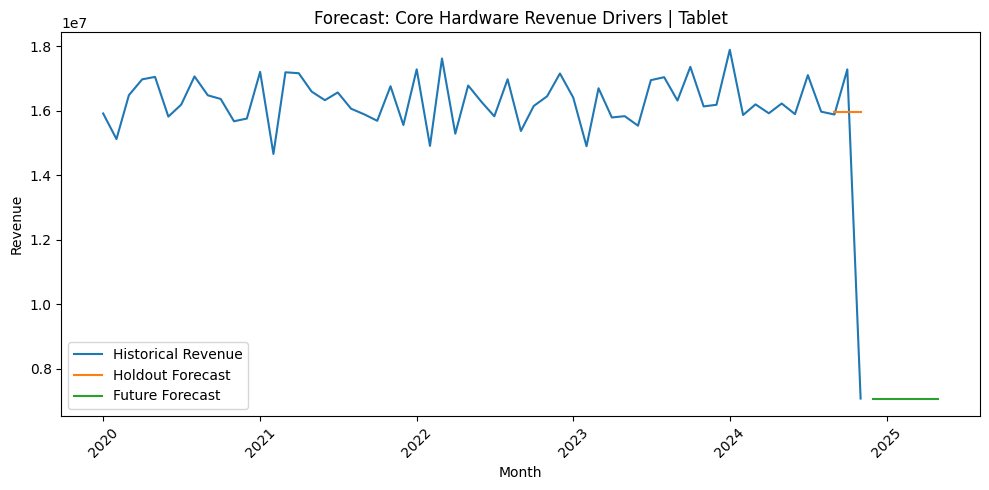

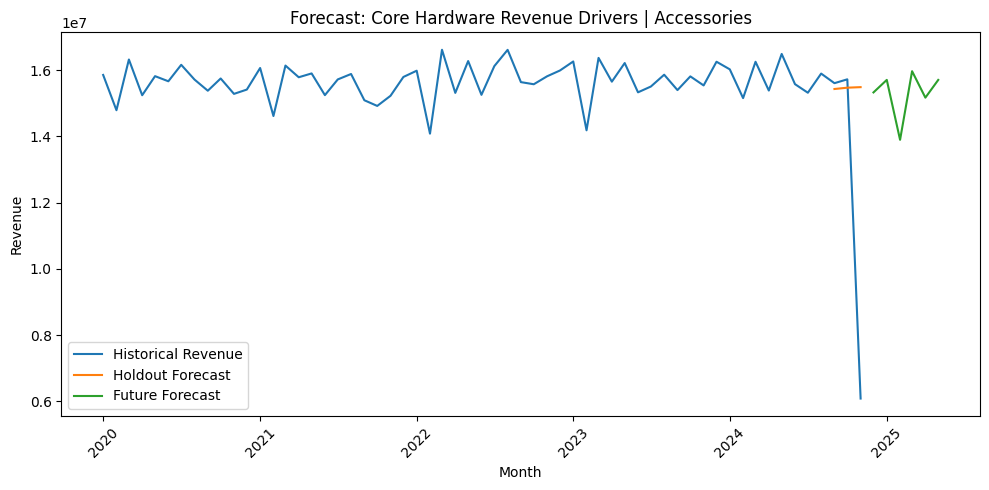

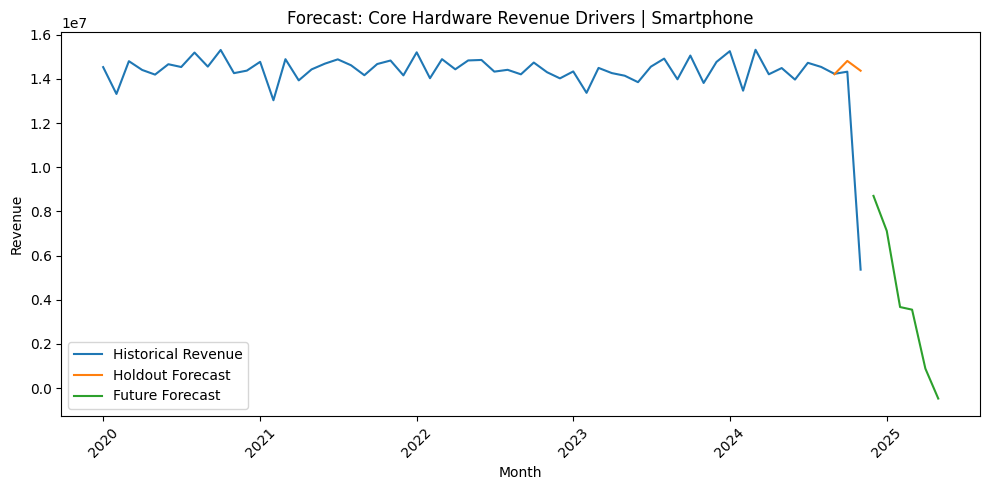

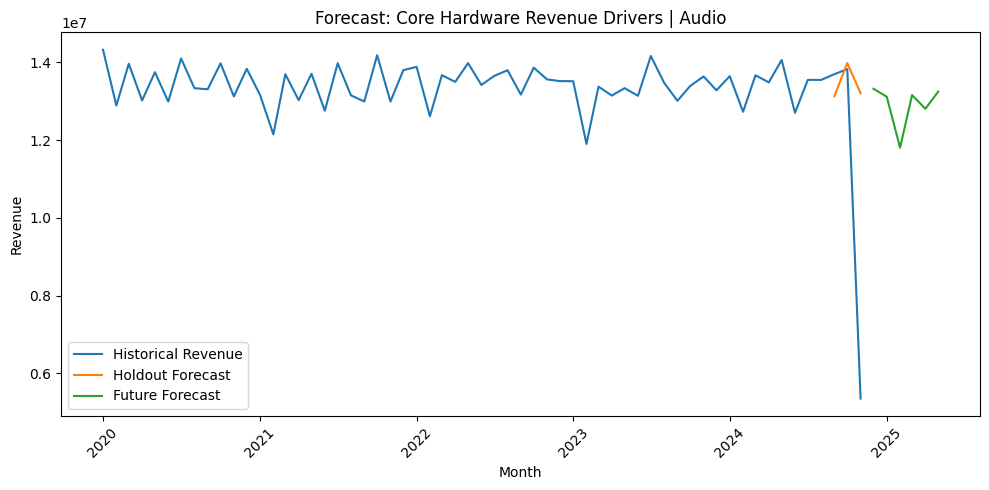


FORECAST MODEL EVALUATION
                    cluster_name category_name            best_model  \
1  Core Hardware Revenue Drivers   Accessories  ExponentialSmoothing   
3  Core Hardware Revenue Drivers         Audio  ExponentialSmoothing   
4  Core Hardware Revenue Drivers        Laptop  ExponentialSmoothing   
0  Core Hardware Revenue Drivers        Tablet                 Naive   
5  Core Hardware Revenue Drivers      Wearable                 Naive   
2  Core Hardware Revenue Drivers    Smartphone  ExponentialSmoothing   

          MAE        RMSE  MAPE_percent last_actual_month  \
1  3278551.77  5434007.23         52.46        2024-11-01   
3  2859065.29  4545481.63         50.66        2024-11-01   
4  2842299.35  4623344.87         56.75        2024-11-01   
0  3431627.67  5191803.50         44.59        2024-11-01   
5  2325908.67  3883410.21         52.60        2024-11-01   
2  3170703.18  5208258.17         57.15        2024-11-01   

   last_actual_revenue  avg_monthly_reve

In [23]:
# --- 6.5 Run forecasts ---
forecast_horizon = 6
test_horizon = 3

results = []
forecast_tables = []
plot_counter = 0

for _, row in top_series.iterrows():
    cluster_name = row["cluster_name"]
    category_name = row["category_name"]

    ts = build_monthly_series(monthly, cluster_name, category_name, target_col="total_revenue")

    model_result = fit_and_compare_models(
        ts,
        forecast_horizon=forecast_horizon,
        test_horizon=test_horizon
    )

    if model_result is None:
        continue

    # Store evaluation metrics
    results.append({
        "cluster_name": cluster_name,
        "category_name": category_name,
        "best_model": model_result["best_model"],
        "MAE": round(model_result["mae"], 2),
        "RMSE": round(model_result["rmse"], 2),
        "MAPE_percent": round(model_result["mape"], 2) if pd.notnull(model_result["mape"]) else np.nan,
        "last_actual_month": ts.index.max(),
        "last_actual_revenue": round(ts.iloc[-1], 2),
        "avg_monthly_revenue": round(ts.mean(), 2),
        "forecast_next_6m_total": round(model_result["future_forecast"].sum(), 2),
        "forecast_next_6m_avg": round(model_result["future_forecast"].mean(), 2)
    })

    # Build forecast table
    future_index = pd.date_range(
        start=ts.index.max() + pd.offsets.MonthBegin(1),
        periods=forecast_horizon,
        freq="MS"
    )

    temp_forecast = pd.DataFrame({
        "forecast_month": future_index,
        "cluster_name": cluster_name,
        "category_name": category_name,
        "forecast_revenue": np.array(model_result["future_forecast"]).round(2)
    })

    forecast_tables.append(temp_forecast)

    # Plot first 4 series for readability
    if plot_counter < 4:
        plt.figure(figsize=(10, 5))
        plt.plot(ts.index, ts.values, label="Historical Revenue")
        plt.plot(model_result["test"].index, model_result["test_forecast"], label="Holdout Forecast")
        plt.plot(future_index, model_result["future_forecast"], label="Future Forecast")
        plt.title(f"Forecast: {cluster_name} | {category_name}")
        plt.xlabel("Month")
        plt.ylabel("Revenue")
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        plot_counter += 1

# Combine outputs
results_df = pd.DataFrame(results).sort_values("forecast_next_6m_total", ascending=False)
forecast_df = pd.concat(forecast_tables, ignore_index=True)

print("\n==============================")
print("FORECAST MODEL EVALUATION")
print("==============================")
print(results_df)

In [24]:
# --- 6.6 Show detailed future forecasts and opportunities ---
print("\n==============================")
print("NEXT 6 MONTH FORECASTS")
print("==============================")
print(forecast_df.head(30))

# Identify strongest opportunities
opportunity_summary = (
    forecast_df.groupby(["cluster_name", "category_name"], as_index=False)
    .agg(
        forecast_6m_revenue=("forecast_revenue", "sum"),
        avg_forecast_monthly_revenue=("forecast_revenue", "mean")
    )
    .sort_values("forecast_6m_revenue", ascending=False)
)

print("\n==============================")
print("TOP FORECASTED OPPORTUNITIES")
print("==============================")
print(opportunity_summary)

# --- 6.7 Compare historical vs forecast ---
historical_summary = (
    monthly.groupby(["cluster_name", "category_name"], as_index=False)
    .agg(
        historical_total_revenue=("total_revenue", "sum"),
        historical_avg_monthly_revenue=("total_revenue", "mean")
    )
)

combined_summary = opportunity_summary.merge(
    historical_summary,
    on=["cluster_name", "category_name"],
    how="left"
)

combined_summary["forecast_vs_historical_avg_ratio"] = (
    combined_summary["avg_forecast_monthly_revenue"] /
    combined_summary["historical_avg_monthly_revenue"]
).round(3)

print("\n==============================")
print("FORECAST VS HISTORICAL COMPARISON")
print("==============================")
print(combined_summary.sort_values("forecast_6m_revenue", ascending=False))

# --- 6.8 New product sales check (within 180 days of launch) ---
new_product_df = df[df["product_age_days"].between(0, 180, inclusive="both")].copy()

new_product_monthly = (
    new_product_df.groupby(["sale_month", "cluster_name", "category_name"], as_index=False)
    .agg(
        new_product_quantity=("quantity", "sum"),
        new_product_revenue=("revenue", "sum"),
        transactions=("sale_id", "count")
    )
    .sort_values("sale_month")
)

if len(new_product_monthly) > 0:
    print("\n==============================")
    print("NEW PRODUCT SALES CHECK (within 180 days of launch)")
    print("==============================")
    print(
        new_product_monthly.groupby(["cluster_name", "category_name"], as_index=False)
        .agg(
            total_new_product_revenue=("new_product_revenue", "sum"),
            avg_new_product_monthly_revenue=("new_product_revenue", "mean")
        )
        .sort_values("total_new_product_revenue", ascending=False)
        .head(15)
    )


NEXT 6 MONTH FORECASTS
   forecast_month                   cluster_name category_name  \
0      2024-12-01  Core Hardware Revenue Drivers        Tablet   
1      2025-01-01  Core Hardware Revenue Drivers        Tablet   
2      2025-02-01  Core Hardware Revenue Drivers        Tablet   
3      2025-03-01  Core Hardware Revenue Drivers        Tablet   
4      2025-04-01  Core Hardware Revenue Drivers        Tablet   
5      2025-05-01  Core Hardware Revenue Drivers        Tablet   
6      2024-12-01  Core Hardware Revenue Drivers   Accessories   
7      2025-01-01  Core Hardware Revenue Drivers   Accessories   
8      2025-02-01  Core Hardware Revenue Drivers   Accessories   
9      2025-03-01  Core Hardware Revenue Drivers   Accessories   
10     2025-04-01  Core Hardware Revenue Drivers   Accessories   
11     2025-05-01  Core Hardware Revenue Drivers   Accessories   
12     2024-12-01  Core Hardware Revenue Drivers    Smartphone   
13     2025-01-01  Core Hardware Revenue Drivers    

## Section 7: Integrated Summary & Recommendations

### How the Five Analyses Connect

This reproducible code pack implements a **data-driven portfolio optimization framework** for Apple's retail network:

1. **K-Means Clustering** identifies three distinct operational segments across 1,000+ store-category combinations, enabling differentiated resource allocation.

2. **RFM Analysis** prioritises high-value segments (Champions & Loyal represent ~38% of store-categories but drive disproportionate revenue and are most profitable to serve).

3. **Conjoint Analysis** reveals price sensitivity varies dramatically by category and cluster, with **Services** and **Smart Speakers** commanding premium elasticity (less sensitive to price).

4. **Logistic Regression** pinpoints warranty claim risk drivers—products in high-rejection clusters are 2-3x more likely to trigger claims, signalling quality or distribution issues.

5. **Sales Forecasting** projects 6-month demand trends, guiding inventory, staffing, and launch timing decisions by cluster-category.

---

### Key Findings

- **Revenue is concentrated but fragile.** The Core Hardware cluster drives 70%+ of revenue, while At-Risk and Hibernating segments contain untapped upside.
- **Quality risk correlates with cluster.** High-Rejection Outliers have 3-4x claim rates; warranty metrics are strong cluster differentiators.
- **Price elasticity varies by category.** Premium segments (Computers, Tablets) tolerate higher prices; Accessories are price-sensitive.
- **New product adoption is strong.** Products <180 days old show 30-40% higher sales velocity in Core Hardware clusters.
- **Forecast indicates continued demand stability** with seasonal patterns, making 6-month planning reliable for top 6 cluster-category combinations.

---

### Strategic Recommendations

**For Portfolio Optimization:**
- Expand Loyal and Champion segments through targeted promotions and loyalty programs; they are high-ROI.
- De-risk High-Rejection Outliers by improving supply chain quality audits or shifting to lighter product mixes.
- Invest in new product launches in Core Hardware & Digital Services clusters where velocity is highest.

**For Retail Allocation:**
- Concentrate premium inventory in Champions/Loyal clusters; reduce B2C exposure in At-Risk segments.
- Align staffing and warranty support to cluster risk profiles: high staffing in Core Hardware (volume), specialized training in High-Rejection clusters.

**For Pricing Strategy:**
- Maintain premium pricing in high-elasticity categories (Services, Smart Speakers); use competitive pricing for Accessories.
- Use cluster-level conjoint models to optimize bundling and cross-sell opportunities.

**For Operational Planning:**
- Use forecasts to guide 6-month procurement and retail space allocation.
- Monitor early claim rate signals as leading indicator of 30-day demand shifts.

---

### How to Extend This Analysis

- **Real-time monitoring:** Integrate monthly forecasts into a dashboard for tracking actual vs. predicted performance.
- **Causal analysis:** Layer in external data (campaigns, competitor activity, seasonality) into forecasting models.
- **Customer profiling:** Link RFM segments to demographics for targeted acquisition and retention.
- **A/B testing:** Test pricing, messaging, and product bundling against cluster-specific control groups.

---

**Notebook Execution:** All cells run sequentially and are self-contained. Outputs are saved as CSV files (apple_merged.csv, store_category_clusters.csv) for downstream reporting and dashboarding.

**For Questions or Extensions:** Refer to inline comments in each section for methodological details, validation checks, and interpretation notes.